# Layer 3c: Full Segmentation (Combined Signals)

Runs the complete `segmenter.py` pipeline — velocity + keypose — on one or two videos.
Visualizes boundaries on the velocity curve, exports an annotated overlay video,
and reports the confidence distribution.

**Set `VIDEO_PATH` (and optionally `STUDENT_VIDEO_PATH`) to the target MP4 files.**

**Expected with empty `keyposes_angles.json`**: all 19 = medium (`matched_signals=['velocity']`)  
**Expected after instructor marks keyposes**: 15+ = high

In [1]:
import sys
import pathlib

project_root = pathlib.Path().resolve().parent.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"project_root: {project_root}")

project_root: E:\Projects\Saas\Taekwon


In [ ]:
import warnings
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from itf_analysis.segmentation.segmentor import load_poses_from_json
from itf_analysis.normalization.normalizer import normalize_pose, extract_joint_angles
from itf_analysis.segmentation.keypose_matcher import load_master_keyposes
from itf_analysis.segmentation.velocity_detector import compute_motion_velocity, smooth_velocity
from itf_analysis.segmentation.segmenter import segment_movements, MovementBoundary

# ── Paths ────────────────────────────────────────────────────────────────────
MASTER_POSES_PATH  = str(project_root / "itf_analysis" / "sample_videos" / "chon_ji_master_poses.json")
MASTER_VIDEO_PATH  = str(project_root / "itf_analysis" / "sample_videos" / "chon_ji_master.mp4")
KEYPOSES_PATH      = str(project_root / "itf_analysis" / "master_data" / "chon_ji" / "keyposes_angles.json")

# Change this to a student poses JSON to compare:
STUDENT_POSES_PATH = MASTER_POSES_PATH   # same as master until student video is available
STUDENT_VIDEO_PATH = MASTER_VIDEO_PATH

FPS = 30.0

# ── End frame ────────────────────────────────────────────────────────────────
# Last frame of actual poomsae content — frames beyond this are excluded from
# timing calculations (prevents return-to-ready motion from shifting windows).
# Set to None to use the full video length.
MASTER_END_FRAME = 1081   # return-to-ready starts at frame 1082

## Step 1: Extract angles

In [3]:
def load_angles(poses_path: str):
    frames = load_poses_from_json(poses_path)
    fps_est = 1000.0 / (frames[1].timestamp_ms - frames[0].timestamp_ms) if len(frames) > 1 else FPS
    angles = []
    for f in frames:
        norm = normalize_pose(f.landmarks)
        if norm is None:
            continue
        angles.append((f.frame_index, extract_joint_angles(norm)))
    return angles, fps_est, len(frames)

master_angles, master_fps, master_total = load_angles(MASTER_POSES_PATH)
print(f"Master : {master_total} frames  fps={master_fps:.1f}  angles={len(master_angles)}")

if STUDENT_POSES_PATH != MASTER_POSES_PATH:
    student_angles, student_fps, student_total = load_angles(STUDENT_POSES_PATH)
    print(f"Student: {student_total} frames  fps={student_fps:.1f}  angles={len(student_angles)}")
else:
    student_angles, student_fps = master_angles, master_fps
    print("Student = master (no separate student video set)")

Master : 1153 frames  fps=30.0  angles=1151
Student = master (no separate student video set)


## Step 2: Load keyposes and run segmentation

In [ ]:
keyposes = load_master_keyposes(KEYPOSES_PATH)
print(f"Keyposes loaded: {len(keyposes)} / 19")
if not keyposes:
    print("  → Running velocity-only mode (all results will be 'medium')")
    print("  → Run keypose_marker workflow to enable 'high' confidence")

print(f"MASTER_END_FRAME: {MASTER_END_FRAME}")

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    master_boundaries = segment_movements(
        master_angles, keyposes, master_fps, end_frame=MASTER_END_FRAME
    )
    student_boundaries = segment_movements(
        student_angles, keyposes, student_fps, end_frame=MASTER_END_FRAME
    )

if caught:
    print(f"\n{len(caught)} warning(s):")
    for w in caught:
        print(f"  {w.message}")
else:
    print("No warnings.")

## Step 3: Boundary table

In [5]:
def print_boundary_table(boundaries, label=""):
    print(f"\n=== {label} ===")
    print(f"{'Mov':>4} {'frame':>6} {'time_ms':>9} {'conf':>8}  signals")
    print("-" * 55)
    for b in boundaries:
        print(f"{b.movement_number:>4} {b.frame:>6} {b.timestamp_ms:>9.0f} "
              f"{b.confidence:>8}  {b.matched_signals}")
    dist = Counter(b.confidence for b in boundaries)
    print(f"\nConfidence: high={dist['high']}  medium={dist['medium']}  low={dist['low']}")

print_boundary_table(master_boundaries, "Master")
if STUDENT_POSES_PATH != MASTER_POSES_PATH:
    print_boundary_table(student_boundaries, "Student")


=== Master ===
 Mov  frame   time_ms     conf  signals
-------------------------------------------------------
   1     87      2900   medium  ['velocity']
   2    145      4833   medium  ['velocity']
   3    202      6733   medium  ['velocity']
   4    254      8467   medium  ['velocity']
   5    310     10333   medium  ['velocity']
   6    364     12133   medium  ['velocity']
   7    417     13900   medium  ['velocity']
   8    470     15667   medium  ['velocity']
   9    528     17600   medium  ['velocity']
  10    583     19433   medium  ['velocity']
  11    643     21433   medium  ['velocity']
  12    744     24800   medium  ['velocity']
  13    803     26767   medium  ['velocity']
  14    855     28500   medium  ['velocity']
  15    911     30367   medium  ['velocity']
  16    962     32067   medium  ['velocity']
  17   1020     34000   medium  ['velocity']
  18   1082     36067   medium  ['velocity']
  19   1121     37367   medium  ['velocity']

Confidence: high=0  medium=19  l

## Plot 1: Velocity curve with boundaries (color = confidence)

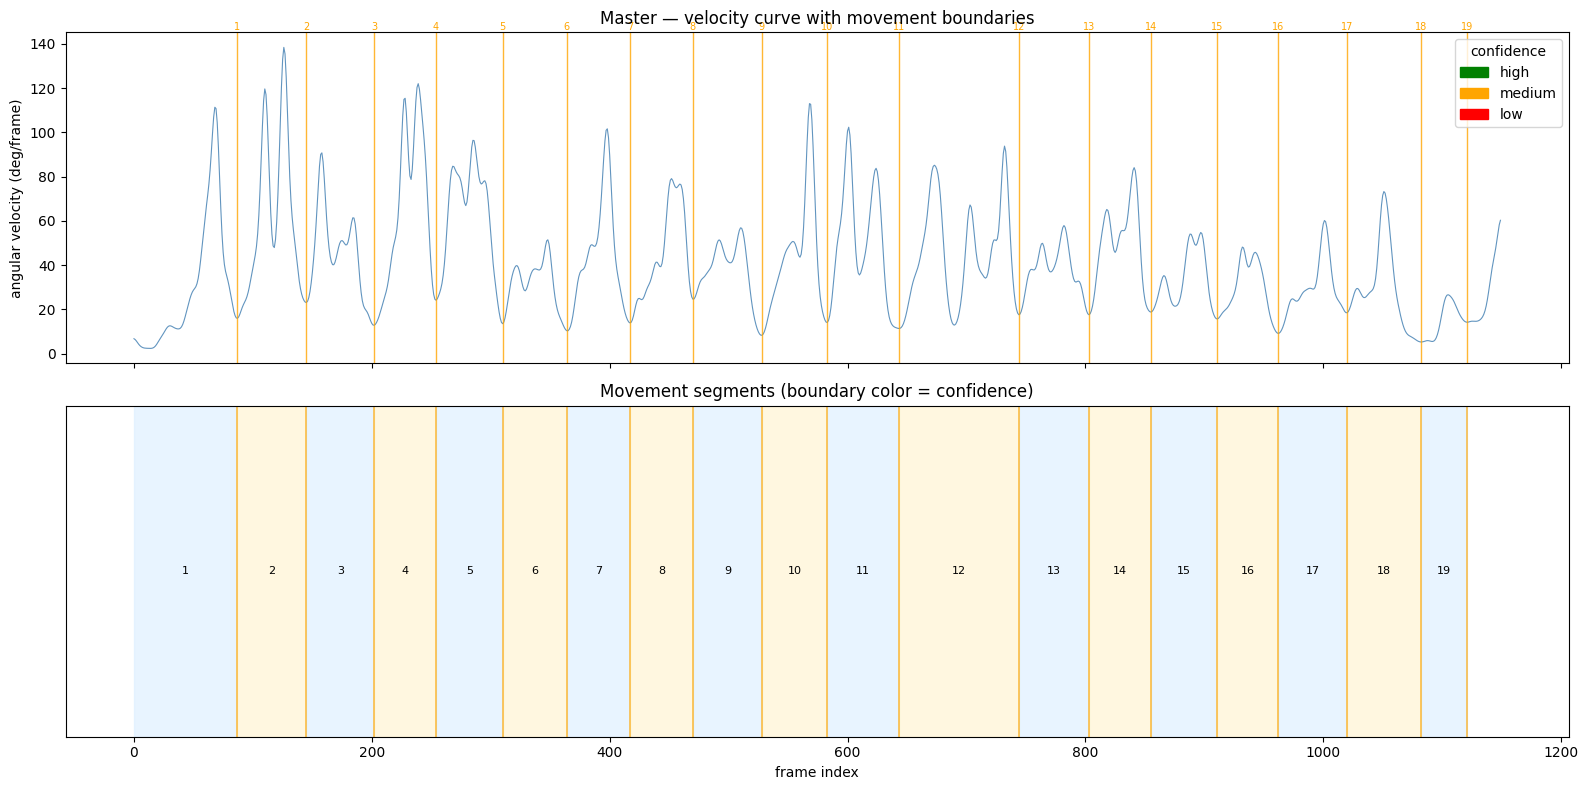

In [6]:
CONF_COLOR = {"high": "green", "medium": "orange", "low": "red"}

def plot_segmentation(angles, boundaries, fps, title="Segmentation"):
    velocity = compute_motion_velocity(angles, fps)
    smoothed = smooth_velocity(velocity, fps)
    fi = np.array([f for f, _ in angles[:len(smoothed)]])

    fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

    # Top: velocity + boundaries
    axes[0].plot(fi, smoothed, linewidth=0.8, color="steelblue", alpha=0.85)
    for b in boundaries:
        col = CONF_COLOR[b.confidence]
        axes[0].axvline(b.frame, color=col, linewidth=1.0, alpha=0.8)
        axes[0].text(b.frame, axes[0].get_ylim()[1] if axes[0].get_ylim()[1] > 0 else 1,
                     str(b.movement_number), ha="center", va="bottom",
                     fontsize=7, color=col)
    patches = [mpatches.Patch(color=c, label=l) for l, c in CONF_COLOR.items()]
    axes[0].legend(handles=patches, title="confidence", loc="upper right")
    axes[0].set_ylabel("angular velocity (deg/frame)")
    axes[0].set_title(f"{title} — velocity curve with movement boundaries")

    # Bottom: movement bands
    band_colors = ["#daeeff", "#fff3cc"]
    prev = 0
    for b in boundaries:
        col = band_colors[(b.movement_number - 1) % 2]
        axes[1].axvspan(prev, b.frame, alpha=0.6, color=col)
        axes[1].text((prev + b.frame) / 2, 0.5, str(b.movement_number),
                     ha="center", va="center", fontsize=8)
        conf_col = CONF_COLOR[b.confidence]
        axes[1].axvline(b.frame, color=conf_col, linewidth=1.2, alpha=0.7)
        prev = b.frame
    axes[1].set_yticks([])
    axes[1].set_xlabel("frame index")
    axes[1].set_title("Movement segments (boundary color = confidence)")

    plt.tight_layout()
    plt.show()

plot_segmentation(master_angles, master_boundaries, master_fps, "Master")
if STUDENT_POSES_PATH != MASTER_POSES_PATH:
    plot_segmentation(student_angles, student_boundaries, student_fps, "Student")

## Plot 2: Confidence distribution

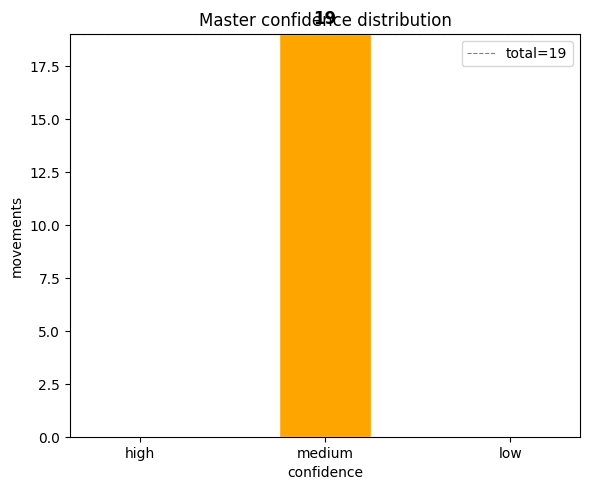

Note: all 'medium' is expected until keyposes_angles.json is populated.
After instructor marks 19 keyposes, 'high' count should reach 15+.


In [7]:
def plot_confidence(boundaries, label):
    dist = Counter(b.confidence for b in boundaries)
    cats = ["high", "medium", "low"]
    counts = [dist[c] for c in cats]
    colors = [CONF_COLOR[c] for c in cats]
    return cats, counts, colors, label

datasets = [plot_confidence(master_boundaries, "Master")]
if STUDENT_POSES_PATH != MASTER_POSES_PATH:
    datasets.append(plot_confidence(student_boundaries, "Student"))

fig, axes = plt.subplots(1, len(datasets), figsize=(6 * len(datasets), 5))
if len(datasets) == 1:
    axes = [axes]

for ax, (cats, counts, colors, label) in zip(axes, datasets):
    bars = ax.bar(cats, counts, color=colors, edgecolor="white", width=0.5)
    ax.set_ylim(0, 19)
    ax.axhline(19, color="gray", linestyle="--", linewidth=0.8, label="total=19")
    for bar, cnt in zip(bars, counts):
        if cnt:
            ax.text(bar.get_x() + bar.get_width()/2, cnt + 0.3,
                    str(cnt), ha="center", va="bottom", fontsize=12, fontweight="bold")
    ax.set_xlabel("confidence")
    ax.set_ylabel("movements")
    ax.set_title(f"{label} confidence distribution")
    ax.legend()

plt.tight_layout()
plt.show()

print("Note: all 'medium' is expected until keyposes_angles.json is populated.")
print("After instructor marks 19 keyposes, 'high' count should reach 15+.")

## Step 4: Video overlay

Writes an annotated MP4 with movement number and confidence overlaid on each frame.
Color: green = high, orange = medium, red = low.

Requires the source video file. Skipped if the file is not found.

In [8]:
import os

def create_overlay_video(
    video_path: str,
    boundaries: list,
    output_path: str,
):
    try:
        import cv2
    except ImportError:
        print("OpenCV not available — skipping video overlay.")
        return

    if not os.path.exists(video_path):
        print(f"Video not found: {video_path}")
        print("Place the source MP4 in sample_videos/ to generate the overlay.")
        return

    cap = cv2.VideoCapture(video_path)
    fps_v = cap.get(cv2.CAP_PROP_FPS) or 30.0
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"Input : {video_path}  ({w}x{h}  {fps_v:.1f}fps  {total} frames)")

    # Build frame → (movement_number, confidence) map
    frame_map = {}
    prev = 0
    for b in boundaries:
        for f in range(prev, b.frame + 1):
            frame_map[f] = (b.movement_number, b.confidence)
        prev = b.frame + 1

    # BGR colors for OpenCV
    BGR = {"high": (0, 200, 0), "medium": (0, 165, 255), "low": (0, 0, 220)}

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out = cv2.VideoWriter(output_path, fourcc, fps_v, (w, h))

    fi = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        info = frame_map.get(fi)
        if info:
            mov_num, conf = info
            color = BGR.get(conf, (200, 200, 200))
            # Dark background box
            cv2.rectangle(frame, (8, 8), (260, 80), (20, 20, 20), -1)
            cv2.rectangle(frame, (8, 8), (260, 80), color, 2)
            cv2.putText(frame, f"Mov {mov_num:02d} / 19",
                        (18, 44), cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)
            cv2.putText(frame, conf.upper(),
                        (18, 72), cv2.FONT_HERSHEY_SIMPLEX, 0.65, color, 1)
            # Progress bar at bottom
            bar_w = int(w * mov_num / 19)
            cv2.rectangle(frame, (0, h - 8), (bar_w, h), color, -1)
        out.write(frame)
        fi += 1

    cap.release()
    out.release()
    print(f"Saved : {output_path}")


master_overlay_path = str(
    project_root / "itf_analysis" / "sample_videos" / "chon_ji_master_segmented.mp4"
)
create_overlay_video(MASTER_VIDEO_PATH, master_boundaries, master_overlay_path)

if STUDENT_POSES_PATH != MASTER_POSES_PATH:
    student_overlay_path = str(
        project_root / "itf_analysis" / "sample_videos" / "chon_ji_student_segmented.mp4"
    )
    create_overlay_video(STUDENT_VIDEO_PATH, student_boundaries, student_overlay_path)

Input : E:\Projects\Saas\Taekwon\itf_analysis\sample_videos\chon_ji_master.mp4  (1920x1080  30.0fps  1153 frames)
Saved : E:\Projects\Saas\Taekwon\itf_analysis\sample_videos\chon_ji_master_segmented.mp4


## Plot 3: Per-movement segment length comparison

If student video is available, compare master vs student segment lengths.
Large differences in a specific movement → student took much longer or shorter.

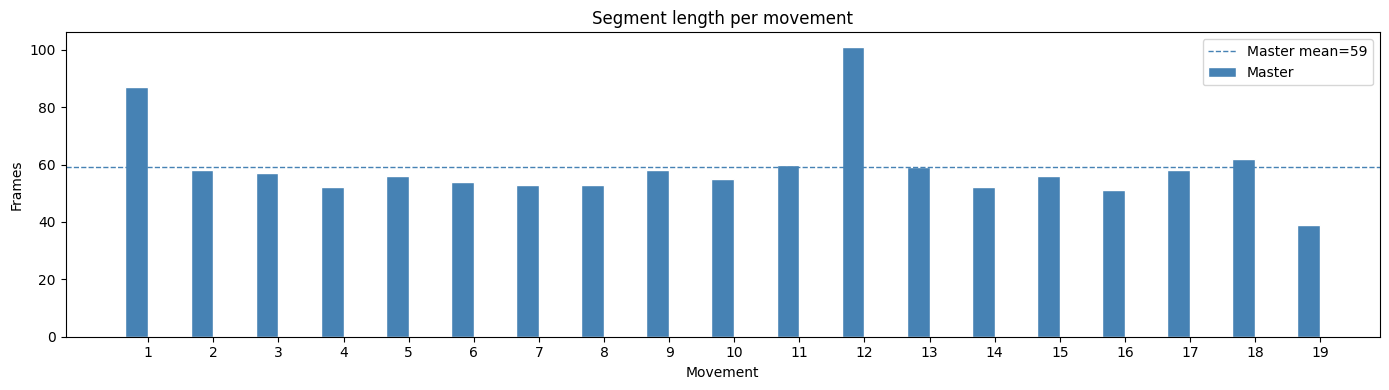

Master  — min: 39  max: 101  mean: 59.0


In [9]:
def segment_lengths(boundaries):
    lengths = []
    prev = 0
    for b in boundaries:
        lengths.append(b.frame - prev)
        prev = b.frame
    return lengths

m_lens = segment_lengths(master_boundaries)
s_lens = segment_lengths(student_boundaries)
movs   = [b.movement_number for b in master_boundaries]

fig, ax = plt.subplots(figsize=(14, 4))
x = np.arange(len(movs))
w = 0.35
ax.bar(x - w/2, m_lens, w, label="Master", color="steelblue", edgecolor="white")
if STUDENT_POSES_PATH != MASTER_POSES_PATH:
    ax.bar(x + w/2, s_lens, w, label="Student", color="coral", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(movs)
ax.set_xlabel("Movement")
ax.set_ylabel("Frames")
ax.set_title("Segment length per movement")
ax.axhline(np.mean(m_lens), color="steelblue", linestyle="--",
           linewidth=1, label=f"Master mean={np.mean(m_lens):.0f}")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Master  — min: {min(m_lens)}  max: {max(m_lens)}  mean: {np.mean(m_lens):.1f}")
if STUDENT_POSES_PATH != MASTER_POSES_PATH:
    print(f"Student — min: {min(s_lens)}  max: {max(s_lens)}  mean: {np.mean(s_lens):.1f}")

## Validation Checklist

- [ ] All 19 boundaries detected (no crash, no low confidence without keyposes)
- [ ] Boundary frames strictly monotonically increasing
- [ ] Segment lengths roughly uniform (no extreme outliers)
- [ ] Velocity curve plot shows boundaries near each velocity valley
- [ ] Overlay video: movement label changes at the right moments

**Gate for 'high' confidence** (requires `keyposes_angles.json`):
- Run instructor keypose marking workflow (keypose_marker.py)
- Re-run this notebook
- Expect high >= 15 / 19 on master-on-master self-test

In [10]:
# Automated checks
lens = segment_lengths(master_boundaries)
monotone = all(master_boundaries[i].frame > master_boundaries[i-1].frame
               for i in range(1, len(master_boundaries)))
no_low = all(b.confidence != "low" for b in master_boundaries)

print("=" * 45)
print(f"19 boundaries       : {'PASS' if len(master_boundaries)==19 else 'FAIL'}")
print(f"Monotonic frames    : {'PASS' if monotone else 'FAIL'}")
print(f"No low confidence   : {'PASS' if no_low else 'FAIL'} "
      f"(low count: {sum(1 for b in master_boundaries if b.confidence=='low')})")
print(f"Segment length std  : {np.std(lens):.1f} frames")
print("=" * 45)
dist = Counter(b.confidence for b in master_boundaries)
print(f"high={dist['high']}  medium={dist['medium']}  low={dist['low']}")

19 boundaries       : PASS
Monotonic frames    : PASS
No low confidence   : PASS (low count: 0)
Segment length std  : 13.1 frames
high=0  medium=19  low=0


## Student Video Segmentation + Alignment

Uses `segment_student_video()`, `align_with_gaps()`, and `validate_alignment()`.

When a real student video is available:
1. Extract poses and angles (same pipeline as master, Step 1 above)
2. Replace `student_frame_angles` in the next cell with the real angle sequence
3. Re-run the cells

For now a **simulated student sequence** (movements 1–19 with movement 5 skipped)
is used to demonstrate the full pipeline.

In [ ]:
import math
from itf_analysis.segmentation.segmenter import segment_student_video
from itf_analysis.alignment.gap_aligner import align_with_gaps, validate_alignment
from itf_analysis.segmentation.keypose_matcher import ANGLE_KEYS

# ── Option A: real student angles (uncomment when available) ─────────────────
# student_frame_angles, _, _ = load_angles(STUDENT_POSES_PATH)

# ── Option B: simulated sequence (movement 5 skipped) ────────────────────────
def _sim_angles(movement_idx: int):
    return {k: float(movement_idx * 50) for k in ANGLE_KEYS}

def _make_sim_sequence(present, fpk=60):
    seq = present + [0]  # neutral return block
    fa = []
    fi = 0
    for i, m in enumerate(seq):
        prev_m = seq[i - 1] if i > 0 else 0
        sa, ea = _sim_angles(prev_m), _sim_angles(m)
        for f in range(fpk):
            t = f / (fpk - 1)
            pos = math.sin(math.pi * t / 2) ** 2
            angles = {k: sa[k] + pos * (ea[k] - sa[k]) for k in ANGLE_KEYS}
            fa.append((fi, angles))
            fi += 1
    return fa

# Simulate: movement 5 is skipped, all others present
present_movements = list(range(1, 5)) + list(range(6, 20))
student_frame_angles = _make_sim_sequence(present_movements)
student_fps_sim = 30.0

print(f"Simulated student sequence: {len(student_frame_angles)} frames")
print(f"Present movements: {present_movements}")

In [ ]:
# Run segment_student_video
sim_keyposes = [{"movement_index": m, "angles": _sim_angles(m)} for m in range(1, 20)]

student_seg_boundaries = segment_student_video(
    student_frame_angles, sim_keyposes, fps=student_fps_sim
)

print(f"Student boundaries detected: {len(student_seg_boundaries)} / 19")
print()
print(f"{'Mov':>4} {'frame':>6} {'conf':>8}  signals")
print("-" * 45)
for b in student_seg_boundaries:
    print(f"{b.movement_number:>4} {b.frame:>6} {b.confidence:>8}  {b.matched_signals}")

### Alignment table

Maps each master movement to the detected student boundary.

In [ ]:
pairs = align_with_gaps(sim_keyposes, student_seg_boundaries)

print(f"{'Master':>7} {'Student':>8} {'Match Type':>12} {'Confidence':>11}")
print("-" * 44)
MATCH_SYMBOL = {"matched": "✓", "skipped": "✗", "extra": "→"}
for p in pairs:
    master_str  = str(p.master_movement)   if p.master_movement   is not None else "-"
    student_str = str(p.student_boundary.movement_number) if p.student_boundary else "-"
    conf_str    = p.student_boundary.confidence if p.student_boundary else "-"
    sym         = MATCH_SYMBOL[p.match_type]
    print(f"{master_str:>7} {student_str:>8} {p.match_type:>12}  {conf_str:>10}  {sym}")

### Validation result

In [ ]:
result = validate_alignment(pairs)

status = "✓ VALID" if result.valid else "✗ INVALID"
print(f"Status  : {status}")
print(f"Message : {result.message or '(없음 — 정상)'}")
print(f"Skipped : {result.skipped_movements or '없음'}")
print(f"Extra   : {result.extra_count}")

### Alignment timeline visualization

- **Green** = matched
- **Red** = skipped (master movement not detected in student)
- **Yellow** = extra (student boundary not assigned to any master movement)

In [ ]:
MATCH_COLOR = {"matched": "#2ecc71", "skipped": "#e74c3c", "extra": "#f1c40f"}

fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# ── Top: dot plot — master movements vs match type ───────────────────────────
ax = axes[0]
for p in pairs:
    x = p.master_movement if p.master_movement is not None else 19.5
    col = MATCH_COLOR[p.match_type]
    ax.scatter(x, 1, s=300, color=col, zorder=3, edgecolors="white", linewidths=1)
    label = str(x) if p.master_movement else "EX"
    ax.text(x, 0.85, label, ha="center", va="top", fontsize=8, color=col)

ax.set_xlim(0, 21)
ax.set_ylim(0.5, 1.5)
ax.set_yticks([])
ax.set_xticks(range(1, 20))
ax.set_xlabel("Master movement number")
ax.set_title("Alignment: each dot = one master movement")
legend_patches = [
    mpatches.Patch(color=c, label=l) for l, c in MATCH_COLOR.items()
]
ax.legend(handles=legend_patches, loc="upper right")

# ── Bottom: student boundary timeline colored by match type ──────────────────
ax2 = axes[1]
total_frames = student_frame_angles[-1][0] + 1

# Build match lookup by student boundary frame
boundary_match = {}
for p in pairs:
    if p.student_boundary is not None:
        boundary_match[p.student_boundary.frame] = p.match_type

prev = 0
for b in student_seg_boundaries:
    mt = boundary_match.get(b.frame, "extra")
    col = MATCH_COLOR[mt]
    ax2.axvspan(prev, b.frame, alpha=0.45, color=col)
    ax2.axvline(b.frame, color=col, lw=1.5)
    ax2.text((prev + b.frame) / 2, 0.5, str(b.movement_number),
             ha="center", va="center", fontsize=9, fontweight="bold")
    prev = b.frame

# Mark skipped movements with red hatching on expected positions
skipped_movs = [p.master_movement for p in pairs if p.match_type == "skipped"]
for mov in skipped_movs:
    exp_x = round(mov / 19 * total_frames)
    ax2.axvline(exp_x, color="#e74c3c", lw=2, linestyle="--", alpha=0.7)
    ax2.text(exp_x, 0.85, f"M{mov}\nmissing", ha="center", va="top",
             fontsize=7, color="#e74c3c")

ax2.set_xlim(0, total_frames)
ax2.set_ylim(0, 1)
ax2.set_yticks([])
ax2.set_xlabel("Frame")
ax2.set_title("Student timeline — green=matched, red=skipped, yellow=extra")

plt.tight_layout()
plt.show()

matched_n = sum(1 for p in pairs if p.match_type == "matched")
skipped_n = sum(1 for p in pairs if p.match_type == "skipped")
extra_n   = sum(1 for p in pairs if p.match_type == "extra")
print(f"Summary: matched={matched_n}  skipped={skipped_n}  extra={extra_n}")